In [1]:
import numpy as np
import xml.etree.ElementTree as ET

tree = ET.parse("survey_xml_H_4FF.txt")
root = tree.getroot()

rows = []

for tank in root.findall(".//tank"):
    tank_x = float(tank.find("./position/x").text)
    tank_y = float(tank.find("./position/y").text)
    R = np.sqrt(tank_x**2 + tank_y**2)

    for channel in tank.findall(".//channel"):
        ch_id = int(channel.attrib["id"])
        rows.append([ch_id, tank_x, tank_y, R])

data = np.array(rows)

np.savetxt("tank_pos_H_4FF.txt", data, fmt = ["%d", "%.1f", "%.1f", "%.1f"])
print("Number of channels:", len(data))
print("Number of tanks:", (len(data)/7))

Number of channels: 31381
Number of tanks: 4483.0


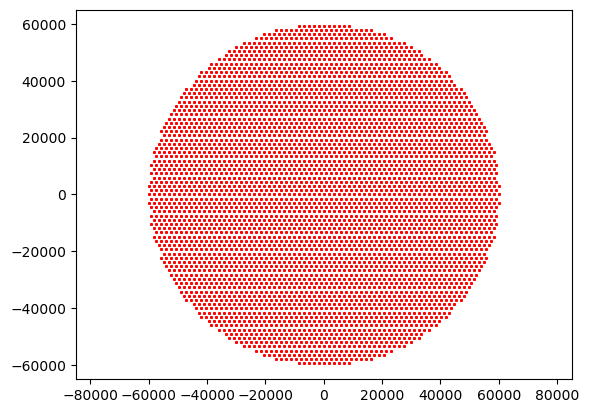

In [2]:
import matplotlib.pyplot as plt
data_channels = np.loadtxt(fname = "tank_pos_H_4FF.txt")
chID, xT, yT, rT = data_channels[:, 0], data_channels[:, 1], data_channels[:, 2], data_channels[:, 3]
plt.xlim(-850*100, 850*100)
plt.ylim(-650*100, 650*100)
plt.scatter(xT, yT, marker = ".", color = "red", s = 2)
plt.show()